In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../../data/moviereviews.csv')

In [4]:
df.head()

,label,review
0,neg,how do films like mouse hunt get into theatres...
1,neg,some talented actresses are blessed with a dem...
2,pos,this has been an extraordinary year for austra...
3,pos,according to hollywood movies made in last few...
4,neg,my first press screening of 1998 and already i...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   2000 non-null   object
 1   review  1965 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [6]:
df = df.dropna()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1965 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   1965 non-null   object
 1   review  1965 non-null   object
dtypes: object(2)
memory usage: 46.1+ KB


In [8]:
df = df[~df['review'].str.isspace()]

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1938 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   1938 non-null   object
 1   review  1938 non-null   object
dtypes: object(2)
memory usage: 45.4+ KB


In [10]:
df['label'].value_counts()

label
neg    969
pos    969
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='count'>

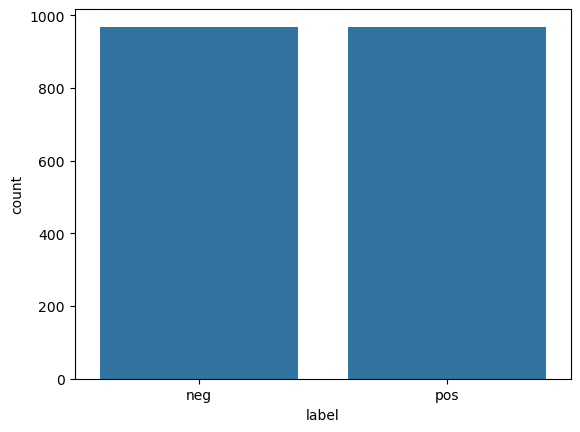

In [11]:
sns.countplot(data=df, x='label')

In [12]:
words = df['review']

In [13]:
uni_words = set()
for row in words:
    one_row = row.lower().split()
    for word in one_row:
        uni_words.add(word)

In [14]:
#uni_words

In [15]:
full_vocab = dict()
i = 0
for word in uni_words:
    full_vocab[word] = i
    i += 1

In [16]:
#full_vocab

In [17]:
all_freq = [0] * len(uni_words)

In [18]:
#all_freq

In [19]:
for word in uni_words:
    word_ind = full_vocab[word]
    all_freq[word_ind] += 1

In [22]:
#all_freq

In [24]:
all_freq = [0] * len(uni_words)

for row in words:
    one_row = row.lower().split()
    
    for word in one_row:
        word_ind = full_vocab[word]
        all_freq[word_ind] += 1

In [26]:
word_counts = []
for word, index in full_vocab.items():
    count = all_freq[index]
    word_counts.append((word, count))

word_counts.sort(key=lambda x: x[1], reverse=True)

for word, count in word_counts[:20]:
    print(f"{word}: {count}")

,: 74417
the: 73302
.: 63437
a: 36429
and: 33801
of: 32579
to: 30587
is: 24331
in: 20738
": 16719
that: 14443
it: 11730
): 11192
(: 11084
as: 10850
with: 10347
for: 9500
his: 9254
this: 9055
film: 8428


In [27]:
X = df['review']
y = df['label']

In [28]:
from sklearn.svm import SVC

In [29]:
from sklearn.pipeline import Pipeline

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [31]:
from sklearn.model_selection import GridSearchCV

In [32]:
steps = [
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('svc', SVC(random_state=101))
]

In [34]:
pipe = Pipeline(steps=steps)

In [35]:
params_svc = {
    'svc__C': [0.1, 1, 10],
    'svc__kernel': ['linear', 'rbf'],
    'svc__class_weight': ['balanced', None]
}

In [36]:
grid_model = GridSearchCV(estimator=pipe, param_grid=params_svc, cv=5, n_jobs=-1)

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [39]:
grid_model.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(stop_words='english')),
                                       ('svc', SVC(random_state=101))]),
             n_jobs=-1,
             param_grid={'svc__C': [0.1, 1, 10],
                         'svc__class_weight': ['balanced', None],
                         'svc__kernel': ['linear', 'rbf']})

In [40]:
pred = grid_model.predict(X_test)

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

              precision    recall  f1-score   support

         neg       0.82      0.82      0.82       191
         pos       0.83      0.83      0.83       197

    accuracy                           0.82       388
   macro avg       0.82      0.82      0.82       388
weighted avg       0.82      0.82      0.82       388




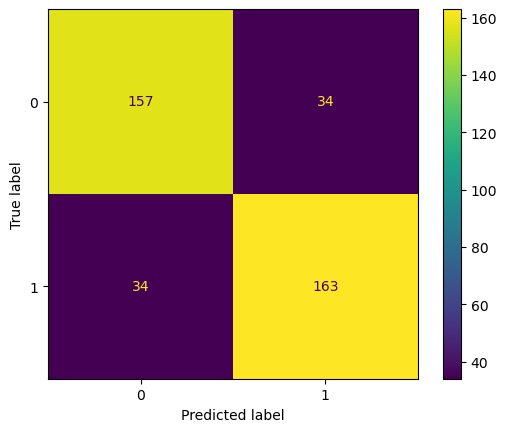

In [42]:
print(classification_report(y_test, pred))
print()
matrix = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(matrix)
disp.plot()
plt.show()

In [44]:
import joblib

In [45]:
svc_model = grid_model.best_estimator_

In [46]:
joblib.dump(svc_model, 'svc_model.pkl')

['svc_model.pkl']

In [43]:
from sklearn.linear_model import LogisticRegression

In [47]:
steps_lr = [
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('lr', LogisticRegression(random_state=101))
]

In [48]:
pipe_lr = Pipeline(steps=steps_lr)

In [49]:
params_lr = {
    'lr__C': [0.1, 1, 10, 100],
    'lr__class_weight': ['balanced', None],
    'lr__solver': ['liblinear', 'lbfgs'],
    'lr__max_iter': [1000] 
}

In [50]:
grid_model_lr = GridSearchCV(estimator=pipe_lr, param_grid=params_lr, cv=5, n_jobs=-1)

In [51]:
grid_model_lr.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(stop_words='english')),
                                       ('lr',
                                        LogisticRegression(random_state=101))]),
             n_jobs=-1,
             param_grid={'lr__C': [0.1, 1, 10, 100],
                         'lr__class_weight': ['balanced', None],
                         'lr__max_iter': [1000],
                         'lr__solver': ['liblinear', 'lbfgs']})

In [52]:
pred_lr = grid_model_lr.predict(X_test)

              precision    recall  f1-score   support

         neg       0.82      0.84      0.83       191
         pos       0.84      0.82      0.83       197

    accuracy                           0.83       388
   macro avg       0.83      0.83      0.83       388
weighted avg       0.83      0.83      0.83       388




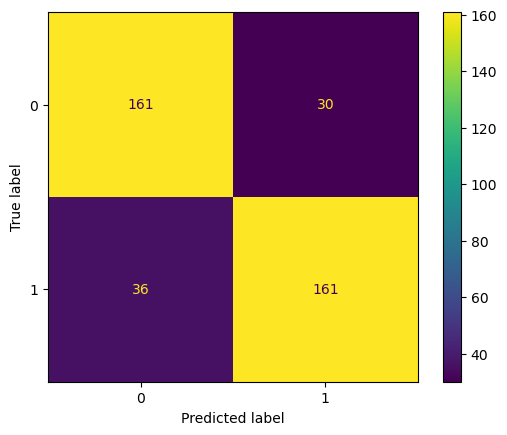

In [53]:
print(classification_report(y_test, pred_lr))
print()
matrix = confusion_matrix(y_test, pred_lr)
disp = ConfusionMatrixDisplay(matrix)
disp.plot()
plt.show()

In [54]:
lr_model = grid_model_lr.best_estimator_

In [55]:
joblib.dump(lr_model, 'lr_model.pkl')

['lr_model.pkl']